In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import duckdb
import urllib.request
import zipfile
import geopandas as gpd

In [5]:
df = pd.read_parquet('../data/yellow_tripdata_2026-01.parquet')

print("Shape:", df.shape)
print("Columns:", df.columns)

Shape: (3724889, 20)
Columns: Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'Airport_fee',
       'cbd_congestion_fee'],
      dtype='object')


In [6]:
# first look at the data
df.head()


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,2,2026-01-01 00:54:04,2026-01-01 00:59:37,1.0,0.97,1.0,N,239,238,1,7.2,1.00,0.5,3.66,0.0,1.0,15.86,2.5,0.0,0.00
1,1,2026-01-01 00:34:04,2026-01-01 00:39:47,0.0,0.90,1.0,N,163,162,2,7.9,4.25,0.5,0.00,0.0,1.0,13.65,2.5,0.0,0.75
2,1,2026-01-01 00:57:06,2026-01-01 01:05:59,0.0,1.40,1.0,N,43,237,1,10.7,4.25,0.5,2.50,0.0,1.0,18.95,2.5,0.0,0.75
3,2,2026-01-01 00:15:22,2026-01-01 00:58:10,4.0,5.58,1.0,N,142,209,1,38.7,1.00,0.5,11.11,0.0,1.0,55.56,2.5,0.0,0.75
4,2,2026-01-01 00:27:13,2026-01-01 00:40:43,0.0,2.16,1.0,N,88,144,1,13.5,1.00,0.5,3.85,0.0,1.0,23.10,2.5,0.0,0.75


In [9]:
# data types
print("DATA TYPES\n")
print(df.dtypes)


DATA TYPES

VendorID                          int32
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag               object
PULocationID                      int32
DOLocationID                      int32
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
Airport_fee                     float64
cbd_congestion_fee              float64
dtype: object


In [14]:

# missing values and percentages in real data, we often have missing values. 
# It's important to identify them and understand their extent before deciding how to handle them in our analysis or modeling.
print("MISSING VALUES")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct})
print(missing_df[missing_df['missing_count'] > 0])

MISSING VALUES
                      missing_count  missing_%
passenger_count             1088058      29.21
RatecodeID                  1088058      29.21
store_and_fwd_flag          1088058      29.21
congestion_surcharge        1088058      29.21
Airport_fee                 1088058      29.21


In [15]:
df.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
count,3.724889e+06,3724889,3724889,2.636831e+06,3.724889e+06,2.636831e+06,3.724889e+06,3.724889e+06,3.724889e+06,3.724889e+06,3.724889e+06,3.724889e+06,3.724889e+06,3.724889e+06,3.724889e+06,3.724889e+06,2.636831e+06,2.636831e+06,3.724889e+06
mean,1.873598e+00,2026-01-17 01:44:52.106518,2026-01-17 02:02:03.696138,1.256271e+00,6.455647e+00,5.218853e+00,1.614372e+02,1.609936e+02,8.465637e-01,2.080425e+01,1.023055e+00,4.833766e-01,2.608142e+00,4.983751e-01,9.479130e-01,2.917853e+01,2.154870e+00,1.482938e-01,5.196437e-01
min,1.000000e+00,2025-12-31 23:57:29,2025-12-31 23:57:32,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,-2.555200e+03,-7.500000e+00,-5.000000e-01,-8.888000e+01,-9.450000e+01,-1.000000e+00,-2.560200e+03,-2.500000e+00,-1.750000e+00,-7.500000e-01
25%,2.000000e+00,2026-01-09 17:51:59,2026-01-09 18:08:47,1.000000e+00,1.000000e+00,1.000000e+00,1.140000e+02,1.070000e+02,0.000000e+00,1.000000e+01,0.000000e+00,5.000000e-01,0.000000e+00,0.000000e+00,1.000000e+00,1.700000e+01,2.500000e+00,0.000000e+00,0.000000e+00
50%,2.000000e+00,2026-01-16 21:20:56,2026-01-16 21:36:14,1.000000e+00,1.810000e+00,1.000000e+00,1.610000e+02,1.620000e+02,1.000000e+00,1.560000e+01,0.000000e+00,5.000000e-01,2.000000e+00,0.000000e+00,1.000000e+00,2.305000e+01,2.500000e+00,0.000000e+00,7.500000e-01
75%,2.000000e+00,2026-01-24 07:25:11,2026-01-24 07:40:22,1.000000e+00,3.730000e+00,1.000000e+00,2.330000e+02,2.340000e+02,1.000000e+00,2.610000e+01,2.500000e+00,5.000000e-01,3.710000e+00,0.000000e+00,1.000000e+00,3.383000e+01,2.500000e+00,0.000000e+00,7.500000e-01
max,7.000000e+00,2026-02-01 00:45:01,2026-02-01 23:35:31,9.000000e+00,2.690975e+05,9.900000e+01,2.650000e+02,2.650000e+02,4.000000e+00,2.555200e+03,1.746000e+01,4.750000e+00,7.660000e+02,1.222200e+02,1.000000e+00,2.560200e+03,2.500000e+00,2.675000e+01,7.500000e-01
std,7.014583e-01,NaN,NaN,6.702431e-01,6.488855e+02,1.965370e+01,6.706657e+01,7.103604e+01,7.120493e-01,1.892701e+01,1.707322e+00,1.145558e-01,3.917405e+00,2.131731e+00,2.654859e-01,2.258553e+01,9.423645e-01,5.336714e-01,3.568099e-01


In [32]:
# Are all nulls coming from the same vendor? 
null_mask = df['passenger_count'].isnull()

print("WHICH VENDOR IS CAUSING NULLS?")
print(df[null_mask]['VendorID'].value_counts())

print("\nWHICH VENDOR IS CLEAN?")
print(df[~null_mask]['VendorID'].value_counts())

WHICH VENDOR IS CAUSING NULLS?
VendorID
2    944635
1    139406
6      4017
Name: count, dtype: int64

WHICH VENDOR IS CLEAN?
VendorID
2    2021107
1     571019
7      44705
Name: count, dtype: int64


In [42]:
# Data quality checks: We want to check for any anomalies or outliers in the data that could indicate data quality issues. 
# This includes checking for negative or zero values in fields like trip_distance and fare_amount, 
# as well as ensuring that the pickup and dropoff times are logical (e.g., pickup time should be before dropoff time).
print("DATA QUALITY CHECKS")
print(f"Zero/negative trip_distance:   {(df['trip_distance'] <= 0).sum()}")
print(f"Zero/negative fare_amount:     {(df['fare_amount'] <= 0).sum()}")
print(f"Zero/negative passenger_count: {(df['passenger_count'] <= 0).sum()}")
print(f"Passengers > 5:                {(df['passenger_count'] > 5).sum()}")
print(f"fare_amount > 500:             {(df['fare_amount'] > 500).sum()}")
print(f"trip_distance > 100:           {(df['trip_distance'] > 100).sum()}")
print(f"Pickup after dropoff:          {(df['tpep_pickup_datetime'] > df['tpep_dropoff_datetime']).sum()}")
print(f"Wrong year:                    {(df['tpep_pickup_datetime'].dt.year != 2026).sum()}")

DATA QUALITY CHECKS
Zero/negative trip_distance:   125738
Zero/negative fare_amount:     41545
Zero/negative passenger_count: 14787
Passengers > 5:                4894
fare_amount > 500:             59
trip_distance > 100:           162
Pickup after dropoff:          1
Wrong year:                    6


In [50]:
# cleaning the data by removing rows with anomalies based on the checks above.
df_clean = df[
    (df['trip_distance'] > 0) & (df['trip_distance'] < 100) &
    (df['fare_amount'] > 0) & (df['fare_amount'] < 500) &
    (df['passenger_count'] >= 1) & (df['passenger_count'] <= 5) &
    (df['tpep_pickup_datetime'] < df['tpep_dropoff_datetime']) &
    (df['tpep_pickup_datetime'].dt.year == 2026)
].copy()

print(f"Original rows:  {len(df)}")
print(f"Clean rows:     {len(df_clean)}")
print(f"Removed rows:   {len(df) - len(df_clean)}")
print(f"Removed %:      {((len(df) - len(df_clean)) / len(df) * 100):.2f}%")

Original rows:  3724889
Clean rows:     2503027
Removed rows:   1221862
Removed %:      32.80%


In [52]:
# Trip duration in minutes  
df_clean['trip_duration_mins'] = (
    df_clean['tpep_dropoff_datetime'] - df_clean['tpep_pickup_datetime']
).dt.total_seconds() / 60

# Time features 
df_clean['pickup_hour'] = df_clean['tpep_pickup_datetime'].dt.hour  # hour the person got in the taxi
df_clean['pickup_day']  = df_clean['tpep_pickup_datetime'].dt.day_name() # day of the week the person got in the taxi
df_clean['pickup_date'] = df_clean['tpep_pickup_datetime'].dt.date # date the person got in the taxi

# Tip features
df_clean['tip_pct'] = (df_clean['tip_amount'] / df_clean['fare_amount'] * 100).round(2) # % of the fare that was given as a tip
df_clean['tipped']  = (df_clean['tip_amount'] > 0).astype(int) # whether the passenger gave a tip or not (1 if tip_amount > 0, else 0)

# Speed
df_clean['speed_mph'] = (
    df_clean['trip_distance'] / (df_clean['trip_duration_mins'] / 60)  # distance in miles / time in hours = speed in mph
).replace([np.inf, -np.inf], np.nan).round(2)

# Fix data types
df_clean['VendorID']    = df_clean['VendorID'].astype(str)   # convert to string since it's a categorical variable
df_clean['payment_type'] = df_clean['payment_type'].astype(str) # convert to string since it's a categorical variable



print("New columns added!")
print(f"\nFinal dataset shape: {df_clean.shape}")
df_clean[['trip_duration_mins', 'pickup_hour', 'pickup_day', 
          'tip_pct', 'tipped', 'speed_mph']].head()

New columns added!

Final dataset shape: (2503027, 27)


,trip_duration_mins,pickup_hour,pickup_day,tip_pct,tipped,speed_mph
0,5.550000,0,Thursday,50.83,1,10.49
3,42.800000,0,Thursday,28.71,1,7.82
5,13.600000,0,Thursday,35.14,1,10.28
6,10.633333,0,Thursday,0.00,0,7.34
8,37.733333,0,Thursday,23.08,1,8.49


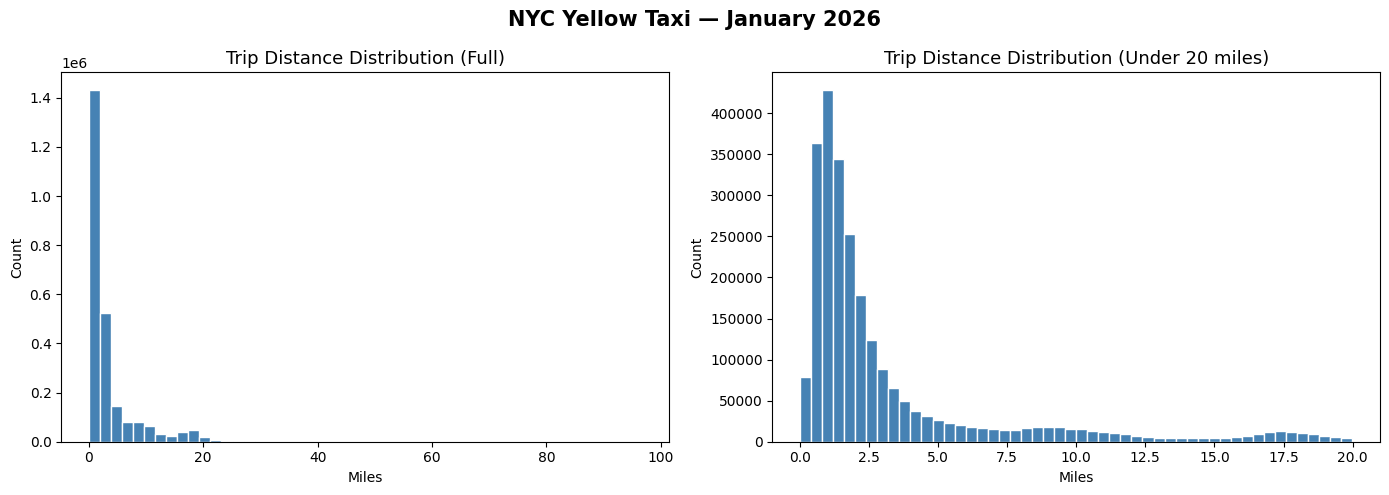

Saved to visuals/


In [72]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full distribution
axes[0].hist(df_clean['trip_distance'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Trip Distance Distribution (Full)', fontsize=13)
axes[0].set_xlabel('Miles')
axes[0].set_ylabel('Count')

# Zoomed in (under 20 miles = 99% of trips)
axes[1].hist(df_clean[df_clean['trip_distance'] < 20]['trip_distance'], # filter to only show trips under 20 miles
             bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('Trip Distance Distribution (Under 20 miles)', fontsize=13)
axes[1].set_xlabel('Miles')
axes[1].set_ylabel('Count')

plt.suptitle('NYC Yellow Taxi — January 2026', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../visuals/01_trip_distance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to visuals/")

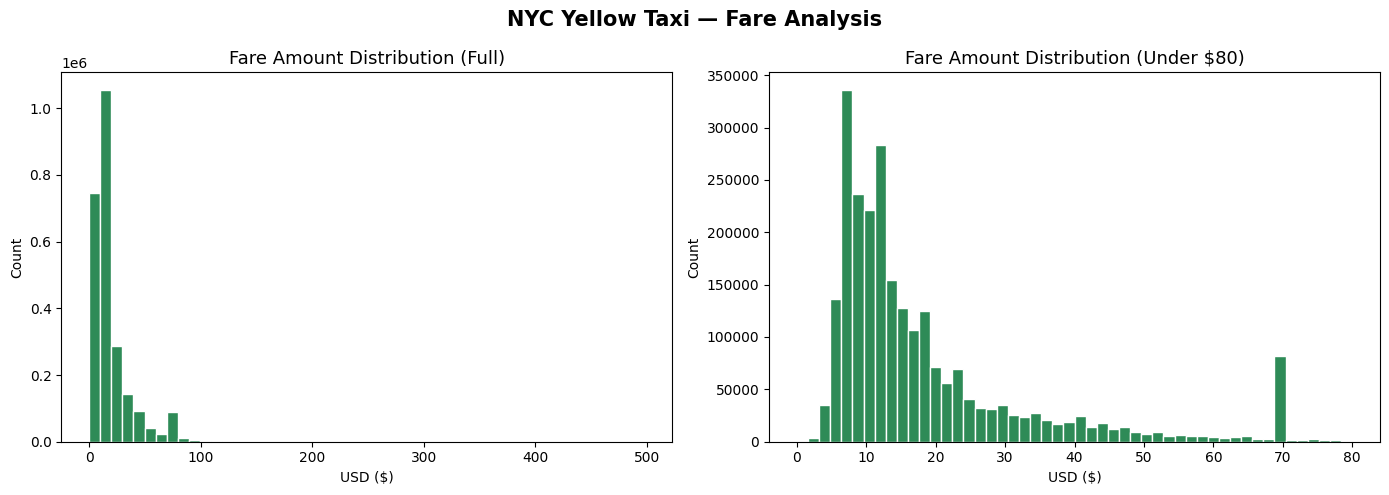

Saved to visuals/


In [74]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_clean['fare_amount'], bins=50, color='seagreen', edgecolor='white')
axes[0].set_title('Fare Amount Distribution (Full)', fontsize=13)
axes[0].set_xlabel('USD ($)')
axes[0].set_ylabel('Count')

axes[1].hist(df_clean[df_clean['fare_amount'] < 80]['fare_amount'],
             bins=50, color='seagreen', edgecolor='white')
axes[1].set_title('Fare Amount Distribution (Under $80)', fontsize=13)
axes[1].set_xlabel('USD ($)')
axes[1].set_ylabel('Count')

plt.suptitle('NYC Yellow Taxi — Fare Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../visuals/02_fare_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to visuals/")

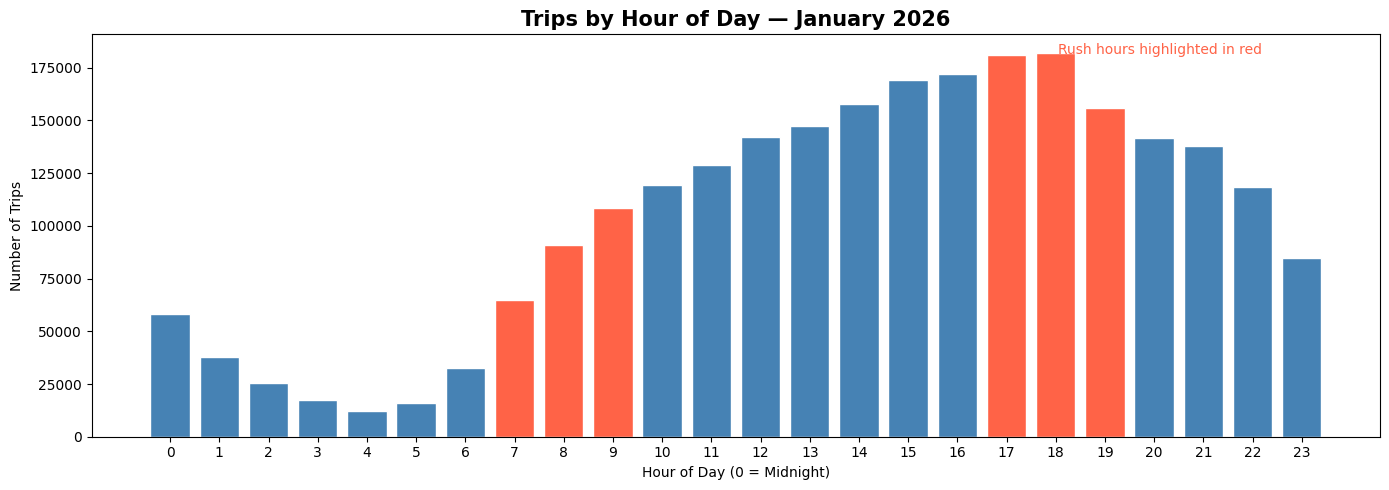

Saved to visuals/


In [75]:
hourly = df_clean.groupby('pickup_hour').size().reset_index(name='trip_count')

plt.figure(figsize=(14, 5))
plt.bar(hourly['pickup_hour'], hourly['trip_count'], 
        color='steelblue', edgecolor='white')

# Highlight rush hours
for hour in [7, 8, 9, 17, 18, 19]:
    plt.bar(hour, hourly[hourly['pickup_hour'] == hour]['trip_count'].values[0],
            color='tomato', edgecolor='white')

plt.title('Trips by Hour of Day — January 2026', fontsize=15, fontweight='bold')
plt.xlabel('Hour of Day (0 = Midnight)')
plt.ylabel('Number of Trips')
plt.xticks(range(24))
plt.annotate('Rush hours highlighted in red', xy=(0.75, 0.95), 
             xycoords='axes fraction', color='tomato', fontsize=10)
plt.tight_layout()
plt.savefig('../visuals/03_trips_by_hour.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to visuals/")

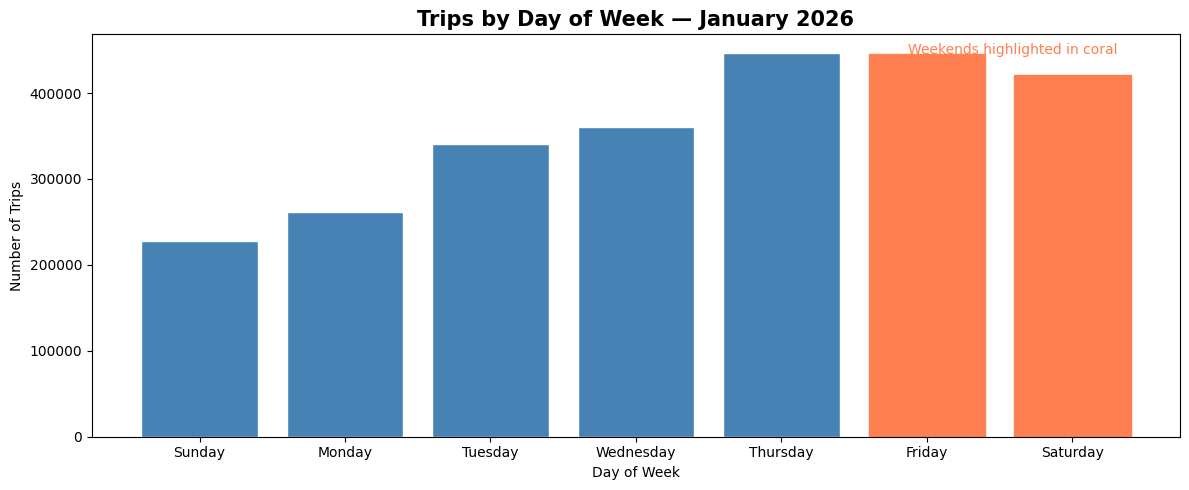

Saved to visuals/


In [80]:
day_order = ['Sunday', 'Monday','Tuesday','Wednesday','Thursday','Friday','Saturday']

daily = df_clean.groupby('pickup_day').size().reindex(day_order).reset_index(name='trip_count')

plt.figure(figsize=(12, 5))
bars = plt.bar(daily['pickup_day'], daily['trip_count'], 
               color='steelblue', edgecolor='white')

# Highlight weekends
for i, day in enumerate(day_order):
    if day in ['Saturday', 'Friday']:
        bars[i].set_color('coral')

plt.title('Trips by Day of Week — January 2026', fontsize=15, fontweight='bold')
plt.xlabel('Day of Week')
plt.ylabel('Number of Trips')
plt.annotate('Weekends highlighted in coral', xy=(0.75, 0.95),
             xycoords='axes fraction', color='coral', fontsize=10)
plt.tight_layout()
plt.savefig('../visuals/04_trips_by_day.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to visuals/")

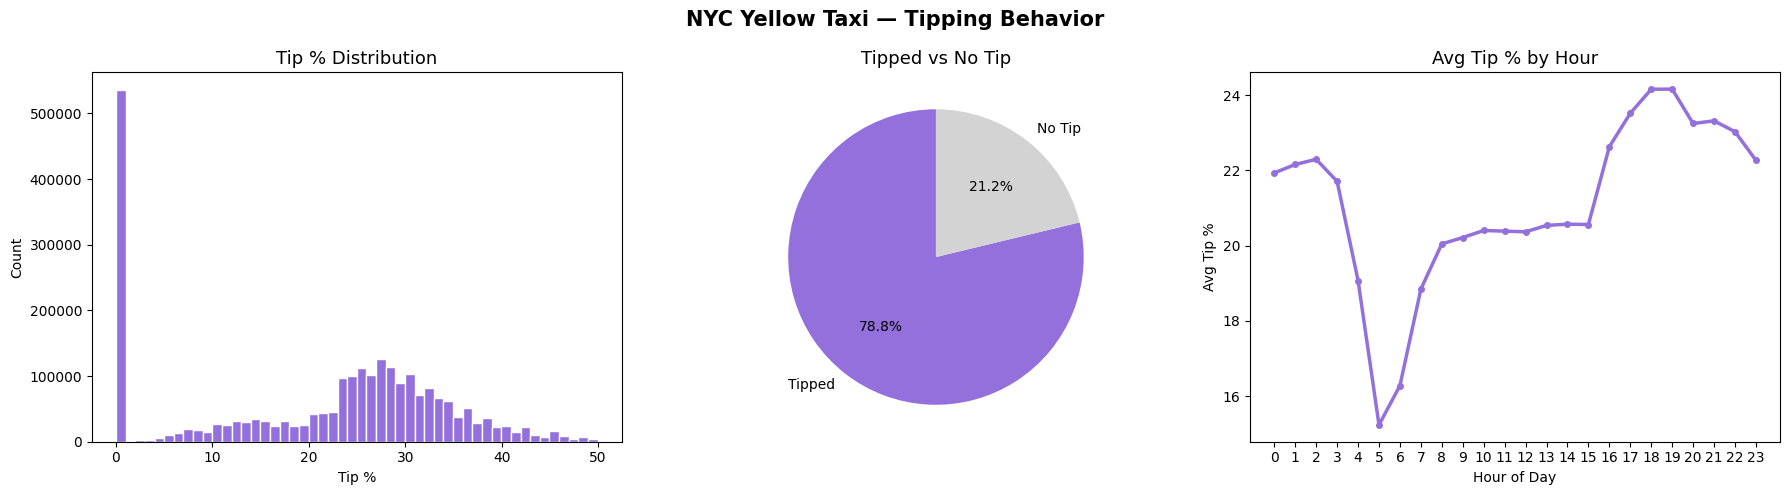

Saved!


In [84]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Tip % distribution  This field is automatically populated for credit card tips. Cashtips are not included.
tip_data = df_clean[df_clean['tip_pct'] < 50]  # remove outliers
axes[0].hist(tip_data['tip_pct'], bins=50, color='mediumpurple', edgecolor='white')
axes[0].set_title('Tip % Distribution', fontsize=13)
axes[0].set_xlabel('Tip %')
axes[0].set_ylabel('Count')

# Tipped vs not tipped
tipped_counts = df_clean['tipped'].value_counts()
axes[1].pie(tipped_counts, 
            labels=['Tipped', 'No Tip'], 
            colors=['mediumpurple', 'lightgray'],
            autopct='%1.1f%%',
            startangle=90)
axes[1].set_title('Tipped vs No Tip', fontsize=13)

# Avg tip % by hour
hourly_tip = df_clean.groupby('pickup_hour')['tip_pct'].mean()
axes[2].plot(hourly_tip.index, hourly_tip.values, 
             color='mediumpurple', linewidth=2.5, marker='o', markersize=4)
axes[2].set_title('Avg Tip % by Hour', fontsize=13)
axes[2].set_xlabel('Hour of Day')
axes[2].set_ylabel('Avg Tip %')
axes[2].set_xticks(range(24))

plt.suptitle('NYC Yellow Taxi — Tipping Behavior', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../visuals/05_tip_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

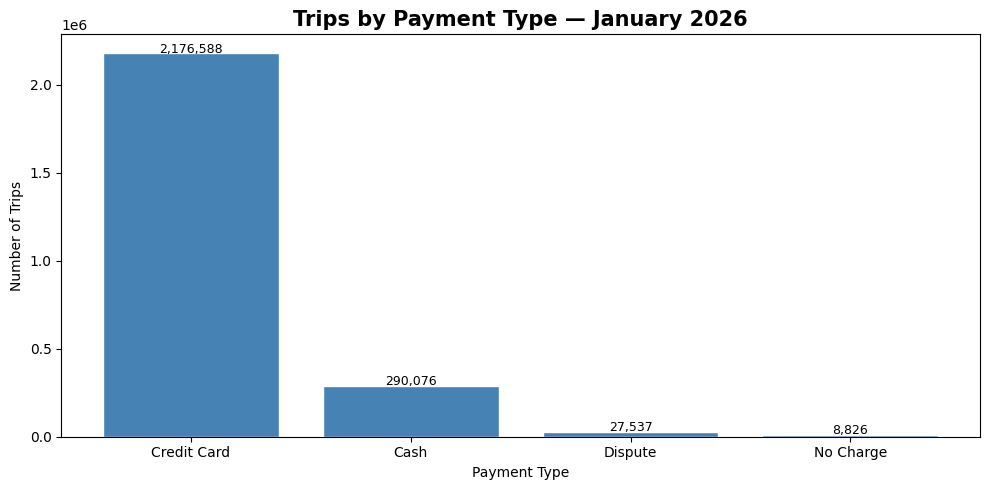

Saved!


In [86]:
payment_map = {
    '0': 'Flex Fare',
    '1': 'Credit Card',
    '2': 'Cash',
    '3': 'No Charge',
    '4': 'Dispute',
    '5': 'Unknown',
    '6': 'Voided'
}

payment_counts = df_clean['payment_type'].map(payment_map).value_counts()

plt.figure(figsize=(10, 5))
bars = plt.bar(payment_counts.index, payment_counts.values,
               color='steelblue', edgecolor='white')

# Add value labels on top of bars
for bar, val in zip(bars, payment_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
             f'{val:,}', ha='center', fontsize=9)

plt.title('Trips by Payment Type — January 2026', fontsize=15, fontweight='bold')
plt.xlabel('Payment Type')
plt.ylabel('Number of Trips')
plt.tight_layout()
plt.savefig('../visuals/06_payment_type.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

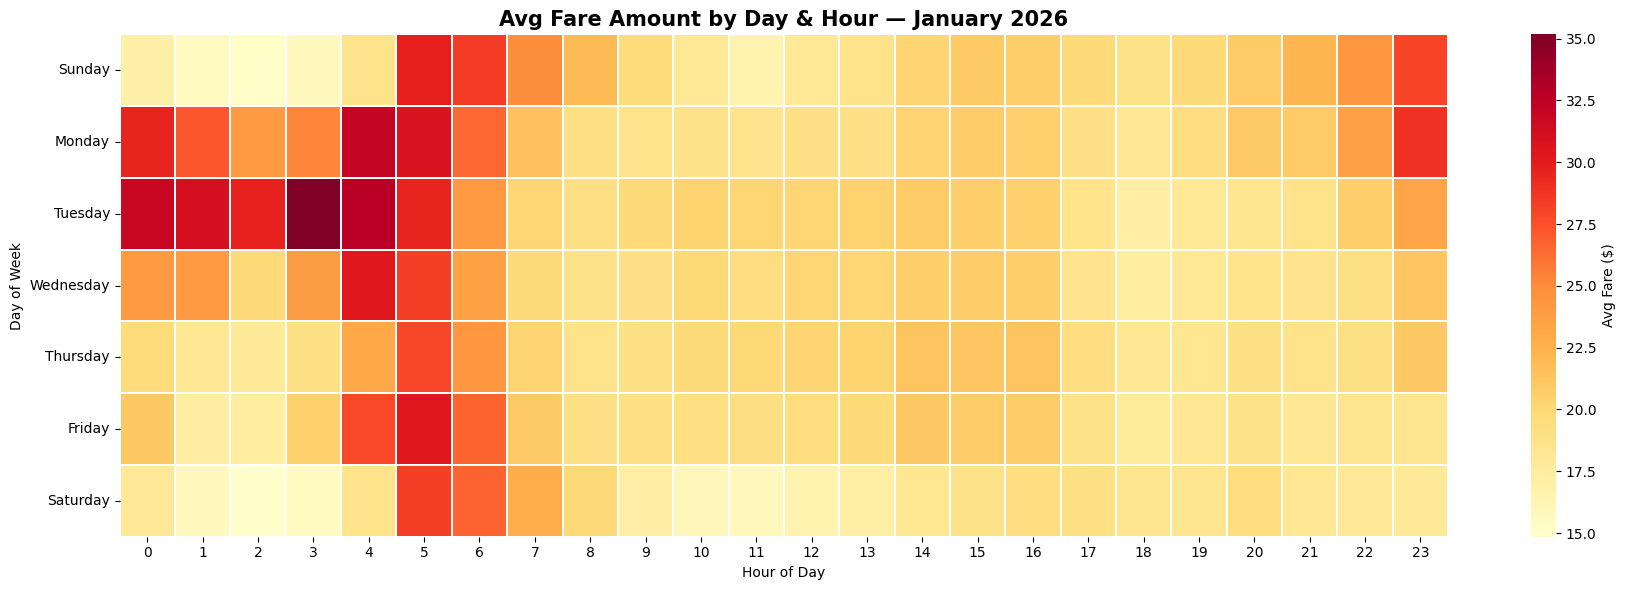

Saved!


In [89]:
day_order = ['Sunday', 'Monday','Tuesday','Wednesday','Thursday','Friday','Saturday']

heatmap_data = df_clean.groupby(['pickup_day', 'pickup_hour'])['fare_amount'] \
                        .mean() \
                        .unstack() \
                        .reindex(day_order)

plt.figure(figsize=(18, 6))
sns.heatmap(heatmap_data, 
            cmap='YlOrRd',
            linewidths=0.3,
            annot=False,
            fmt='.1f',
            cbar_kws={'label': 'Avg Fare ($)'})

plt.title('Avg Fare Amount by Day & Hour — January 2026', fontsize=15, fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.tight_layout()
plt.savefig('../visuals/07_fare_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

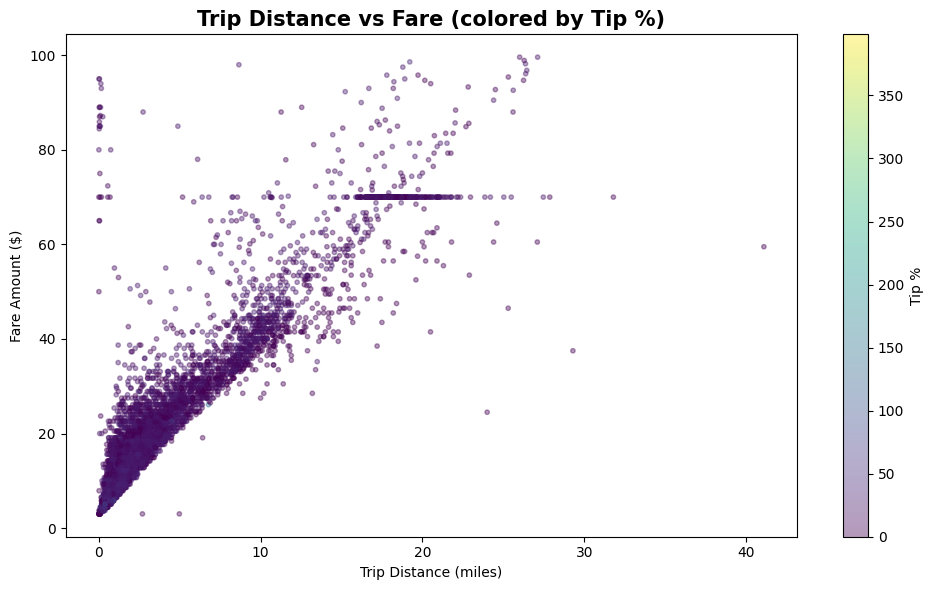

✅ Saved!


In [90]:
 # samping inorder to speed up the plotting and avoid overplotting. 
 # Overplotting can occur when you have a large dataset and many points are plotted on top of each other, making it difficult to see patterns or trends. 
 # By taking a random sample of the data, we can create a clearer visualization while still capturing the overall relationships between variables.
sample = df_clean[df_clean['fare_amount'] < 100].sample(10000, random_state=42)


plt.figure(figsize=(10, 6))
scatter = plt.scatter(sample['trip_distance'], 
                      sample['fare_amount'],
                      c=sample['tip_pct'],
                      cmap='viridis',
                      alpha=0.4,
                      s=10)

plt.colorbar(scatter, label='Tip %')
plt.title('Trip Distance vs Fare (colored by Tip %)', fontsize=15, fontweight='bold')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Fare Amount ($)')
plt.tight_layout()
plt.savefig('../visuals/08_distance_vs_fare.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

In [97]:
# majority of tips come from credit card payments, so we want to analyze tipping behavior by payment type.
payment_map = {
    '0': 'Flex Fare', '1': 'Credit Card', '2': 'Cash',
    '3': 'No Charge', '4': 'Dispute', '5': 'Unknown', '6': 'Voided'
}

df_clean['payment_label'] = df_clean['payment_type'].map(payment_map)

tip_by_payment = df_clean.groupby('payment_label').agg(
    avg_tip       = ('tip_amount', 'mean'),
    pct_tipped  = ('tipped', 'mean'),
    trip_count    = ('tipped', 'count')
).round(3).sort_values('avg_tip', ascending=False)

print("TIP BEHAVIOR BY PAYMENT TYPE\n")
print(tip_by_payment)

TIP BEHAVIOR BY PAYMENT TYPE

               avg_tip  pct_tipped  trip_count
payment_label                                 
Credit Card      4.114       0.906     2176588
Dispute          0.002       0.000       27537
Cash             0.000       0.000      290076
No Charge        0.000       0.000        8826


In [101]:
from scipy import stats

corr_coef, p_value = stats.pearsonr(
    df_clean['trip_distance'], 
    df_clean['fare_amount']
)

print(f"DISTANCE vs FARE CORRELATION\n")
print(f"Pearson Correlation: {corr_coef:.4f}")
print(f"P-value:             {p_value:.2e}")
print(f"\n{'Strong positive correlation!' if corr_coef > 0.7 else '⚠️ Moderate correlation'}")
print(f"Interpretation: {corr_coef*100:.1f}% of fare variance explained by distance")

DISTANCE vs FARE CORRELATION

Pearson Correlation: 0.9192
P-value:             0.00e+00

Strong positive correlation!
Interpretation: 91.9% of fare variance explained by distance


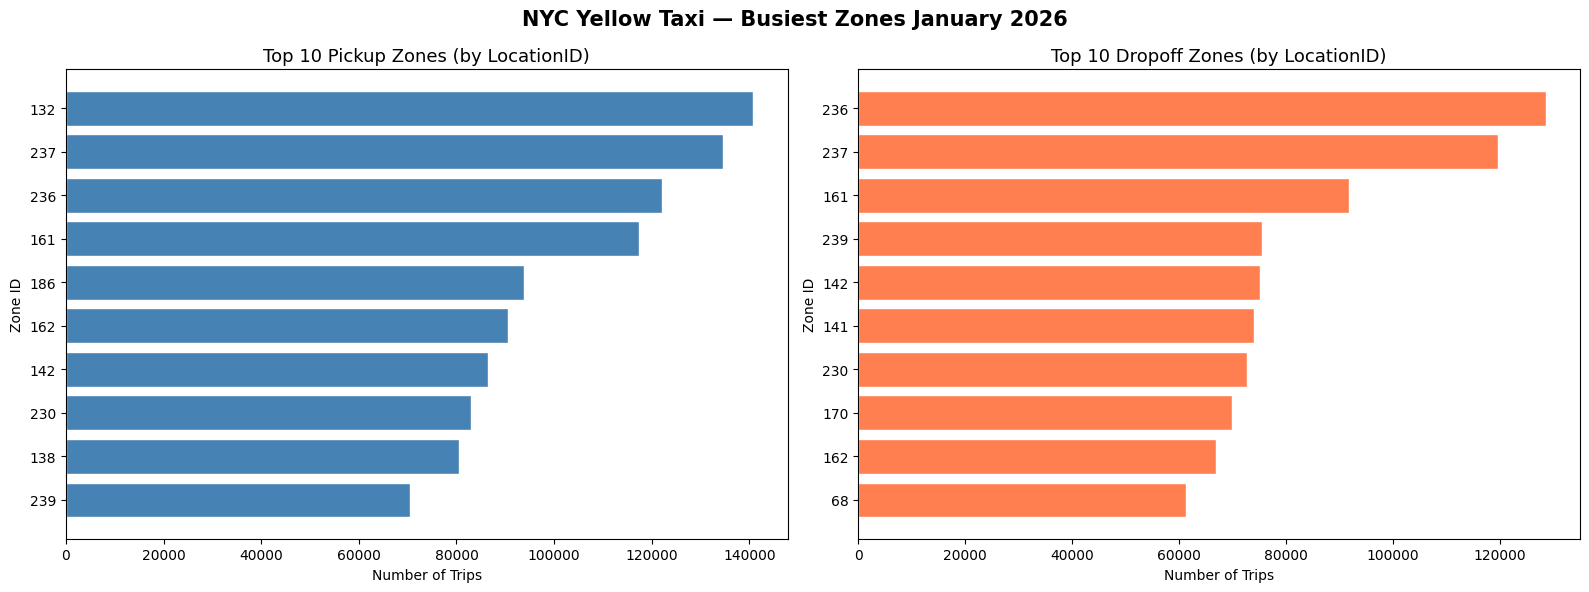

Saved!


In [104]:
# Map LocationIDs to real zone names
zone_url = "https://raw.githubusercontent.com/plotly/datasets/master/uber-rides-data/taxi_zones.csv"

# We'll manually map the most common ones instead
top_pickups = df_clean['PULocationID'].value_counts().head(10).reset_index()
top_pickups.columns = ['LocationID', 'trip_count']

top_dropoffs = df_clean['DOLocationID'].value_counts().head(10).reset_index()
top_dropoffs.columns = ['LocationID', 'trip_count']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(top_pickups['LocationID'].astype(str), 
             top_pickups['trip_count'],
             color='steelblue', edgecolor='white')
axes[0].set_title('Top 10 Pickup Zones (by LocationID)', fontsize=13)
axes[0].set_xlabel('Number of Trips')
axes[0].set_ylabel('Zone ID')
axes[0].invert_yaxis()

axes[1].barh(top_dropoffs['LocationID'].astype(str),
             top_dropoffs['trip_count'],
             color='coral', edgecolor='white')
axes[1].set_title('Top 10 Dropoff Zones (by LocationID)', fontsize=13)
axes[1].set_xlabel('Number of Trips')
axes[1].set_ylabel('Zone ID')
axes[1].invert_yaxis()

plt.suptitle('NYC Yellow Taxi — Busiest Zones January 2026', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../visuals/11_top_zones.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

In [106]:
import os

os.makedirs("data", exist_ok=True)

In [112]:
# Download the official TLC taxi zone lookup
import urllib.request

url = "https://d37ci6vzurychx.cloudfront.net/misc/taxi+_zone_lookup.csv"
urllib.request.urlretrieve(url, "data/taxi_zone_lookup.csv")

zones = pd.read_csv("data/taxi_zone_lookup.csv")
print(zones.head(10))
print("\nShape:", zones.shape)

   LocationID        Borough                     Zone service_zone
0           1            EWR           Newark Airport          EWR
1           2         Queens              Jamaica Bay    Boro Zone
2           3          Bronx  Allerton/Pelham Gardens    Boro Zone
3           4      Manhattan            Alphabet City  Yellow Zone
4           5  Staten Island            Arden Heights    Boro Zone
5           6  Staten Island  Arrochar/Fort Wadsworth    Boro Zone
6           7         Queens                  Astoria    Boro Zone
7           8         Queens             Astoria Park    Boro Zone
8           9         Queens               Auburndale    Boro Zone
9          10         Queens             Baisley Park    Boro Zone

Shape: (265, 4)


In [113]:
top_pickups_named = top_pickups.merge(
    zones, left_on='LocationID', right_on='LocationID', how='left'
)[['LocationID', 'Zone', 'Borough', 'trip_count']]

top_dropoffs_named = top_dropoffs.merge(
    zones, left_on='LocationID', right_on='LocationID', how='left'
)[['LocationID', 'Zone', 'Borough', 'trip_count']]

print("=== TOP 10 PICKUP ZONES ===")
print(top_pickups_named.to_string(index=False))

print("\n=== TOP 10 DROPOFF ZONES ===")
print(top_dropoffs_named.to_string(index=False))

=== TOP 10 PICKUP ZONES ===
 LocationID                         Zone   Borough  trip_count
        132                  JFK Airport    Queens      140768
        237        Upper East Side South Manhattan      134606
        236        Upper East Side North Manhattan      122002
        161               Midtown Center Manhattan      117450
        186 Penn Station/Madison Sq West Manhattan       93911
        162                 Midtown East Manhattan       90497
        142          Lincoln Square East Manhattan       86529
        230    Times Sq/Theatre District Manhattan       82897
        138            LaGuardia Airport    Queens       80560
        239        Upper West Side South Manhattan       70465

=== TOP 10 DROPOFF ZONES ===
 LocationID                      Zone   Borough  trip_count
        236     Upper East Side North Manhattan      128500
        237     Upper East Side South Manhattan      119634
        161            Midtown Center Manhattan       91730
        2